In [3]:
import IPython.display
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.spatial import distance as dist
from matplotlib.patches import ConnectionPatch

from Background_functions import call_length_stats, start_end_times, split_audio_segments, read_audio_file
from STFT import resample_audio, stft_calculation, plot_spectrogram
from DFT import dp

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")


In [ ]:
#store start and end times in array
text = DATA_22 / "20230422_171301.Detections.selections.txt"
df, start_, end_t = start_end_times(text)
average_call_length, longest_call_length, shortest_call_length = call_length_stats(df)
print(f"Average call length: {average_call_length:.2f} seconds")
print(f"Longest call length: {longest_call_length:.2f} seconds")
print(f"Shortest call length: {shortest_call_length:.2f} seconds")

Average call length: 0.23 seconds
Longest call length: 2.46 seconds
Shortest call length: 0.10 seconds


In [5]:
#Clip wanted audio segment from the original audio file
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)

audio_segments = split_audio_segments(x, f_s, start_t, end_t)

This is first try of calculateing STFT

In [6]:
#Calculate the STFT of the audio segment
fs_new = 2000
resampled_audio = resample_audio(audio_segments[0], f_s, fs_new)
f, t, Zxx = stft_calculation(resampled_audio, f_s, fs_new)

This is the first implementation of STFT with DTW

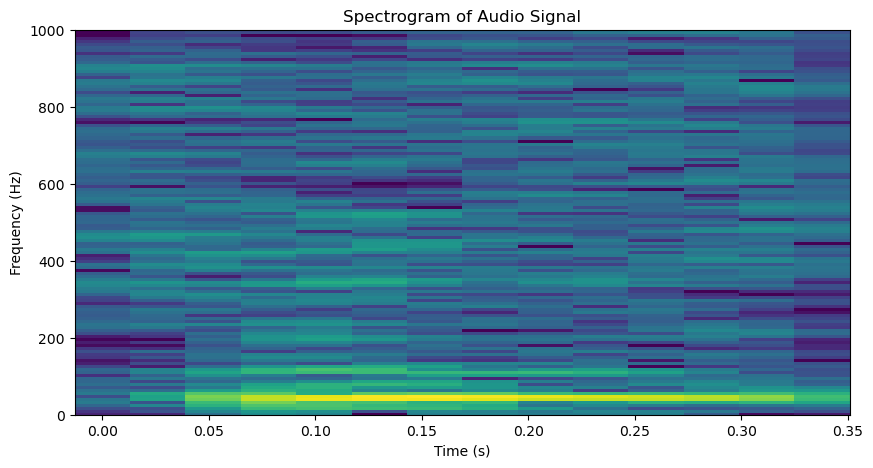

In [7]:
template = resample_audio(audio_segments[0], f_s, fs_new)
comparison = resample_audio(audio_segments[100], f_s, fs_new)

template_f, template_t, template_Zxx = stft_calculation(template, f_s, fs_new)
comparison_f, comparison_t, comparison_Zxx = stft_calculation(comparison, f_s, fs_new)

plot_spectrogram(template_f, template_t, template_Zxx, fs_new)


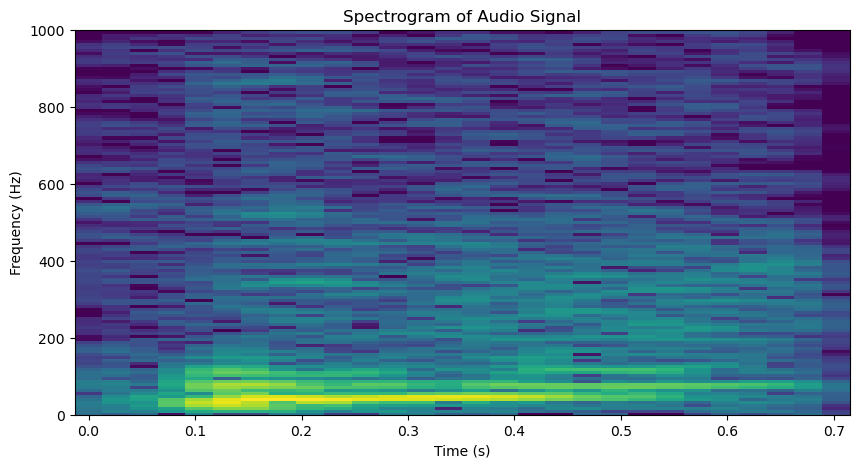

In [8]:
plot_spectrogram(comparison_f, comparison_t, comparison_Zxx, fs_new)

In [9]:
x_seq = np.abs(template_Zxx).T      # shape: (n_time_frames, n_freq_bins)
y_seq = np.abs(comparison_Zxx).T    # shape: (n_time_frames, n_freq_bins)

dist_mat = dist.cdist(x_seq, y_seq, "cosine")
path, cost_mat = dp(dist_mat)
ali_cost = cost_mat[-1, -1]
print("Alignment cost: {:.4f}".format(ali_cost))

M = x_seq.shape[0]
N = y_seq.shape[0]
norm_ali_cost = ali_cost / (M + N)
print("Normalized alignment cost: {:.4f}".format(norm_ali_cost))

Alignment cost: 6.7764
Normalized alignment cost: 0.1613
